## Example Privacy Auditing of PCA: Membership Inference and Leave-One-Out Analysis

1. Creates some synthetic data for testing.
2. Runs scikit-learn's PCA and saves the reconstruction errors.
3. Runs diffprivlib's PCA and saves the reconstruction errors.
4. Simulates a simple threshold MIA against the PCA errors.
5. Runs a leave-one-out audit of the scikit-learn PCA errors.
6. Runs a SACRO-ML MIA against the scikit-learn PCA errors.


### General Notes

In [1] a number of image derived phenotypes (IDPs) are generated and a PCA +
linear regression model is subsequently fit. Despite that these IDPs are
"derived features", they could behave as a biometric signature, which would
make them much closer to face embeddings than to an anonymised summary. Thus, 
in the scenario that the IDPs are considered to be too disclosive to be
egressed, the PCA values and regression coefficients may be requested for
release. The PCA model would then need to be assessed for privacy leakage. 

A potential mitigation is the use of differential privacy, which reduces the 
influence any individual sample has on the model; so an example of the IBM 
diffprivlib PCA is included here. The details can be found in [5].

The SACRO-ML WorstCaseAttack is a weak membership inference attack that fits a 
binary classification model using the reconstruction errors to predict training 
membership. The attack classifier can (and should) be tuned to maximise 
performance, however here a simple default is used as an example. This is the
only attack from SACRO-ML (v1.4.3) that is possible to use in this scenario
since it only currently supports classification models and this particular
attack is originally intended to operate on a classification model's predicted
probabilities, but it will also work here using the errors. This is included 
here primarily to show how the SACRO-ML pipeline could be integrated. Results 
are saved as JSON and PDF files in the OUTPUT_PATH.

Other than [2], [3], and [4], there appears to be very little work investigating
the privacy leakage of PCA methods. Following [8], a simple threshold MIA has
become a standard baseline for MIA. Consequently, [2] uses a threshold MIA on 
the PCA errors; here that is implemented by simply passing the errors to the 
scikit-learn ROC curve which evaluates the TPR/FPR for all unique thresholds.

State-of-the-art MIAs like LiRA [6] and RMIA [7] train N reference models over 
different data splits to observe a sample's loss when it is included versus
excluded from training. These conditional loss distributions then serve as the
baseline for hypothesis testing to determine whether the sample was part of the 
target model's training set. However PCA fitting is deterministic, so a 
leave-one-out analysis is more appropriate, if computationally feasible.

Thus, also included is a novel leave-one-out audit of the PCA errors, where a new PCA
is fit N-1 times with each sample removed in turn. The reconstruction errors of
the samples when excluded can then be compared with the full fitted model (to 
be egressed) to find samples that have a large influence on the PCA. These 
samples would be expected to be the ones that are most vulnerable to any
privacy attack. This can also provide information about how stable the PCA is.

### Practical Notes

In [1] there are: ~15,000 members and ~1,000 non-members. 50 PCA components.
Is it cost-feasible to compute 15,000 PCAs for leave-one-out auditing?

The non-members may not be a random hold-out from the same pool. They may be a 
separate longitudinal cohort with slightly different selection criteria (e.g.,
participants who returned for a second scan). The authors tried to match
demographics and health characteristics, but there may still be subtle 
distributional differences.

Not considered here: group privacy rather than individual privacy, i.e., rare
subpopulation effects; e.g., (i) a very rare brain phenotype; (ii) a rare 
neurological condition; (iii) a small demographic subgroup. These could 
influence a PCA with that subgroup having a disproportionate influence. Group 
privacy is not widely explored generally. Group privacy may require domain
specific knowledge similar to attribute inference in order to identify which 
attributes are sensitive before any assessment can be made.

If the IDPs are to be released, potential safety arguments might be (a) that they are 
non-invertible: does a sample get mapped to the same IDP as at least k-1 others?
(b) the medical images would need to be obtained in order to compute the IDPs to
mount an attack and if that is the case then the privacy has already been breached.
If the IDPs were considered to be too disclosive and no suitable mitigations could
be applied, the last resort would be for the TRE to host them internally as a new
dataset.

### References

[1] Mohammadi-Nejad et al. (2025) Accelerated brain ageing during the COVID-19
pandemic.

[2] Zari et al. (2022) Membership inference attack against principal component 
analysis.

[3] Kwatra and Torra (2023) Data reconstruction attack against principal
component analysis.

[4] Lumbut and Ponnoprat (2025) Investigating privacy leakage in dimensionality 
reduction methods via reconstruction attack.

[5] Liu et al. (2022) DP-PCA: Statistically optimal and differentially private PCA.

[6] Carlini et al. (2022) Membership inference attacks from first principles.

[7] Zarifzadeh et al. (2024) Low-cost high-power membership inference attacks.

[8] Yeom et al. (2018) Privacy risk in machine learning: Analyzing the connection to overfitting.

### Requirements

See requirements.txt

Note: sacroml is a large install because it depends on scikit-learn, pytorch, etc.

In [1]:
import diffprivlib as dp
import matplotlib.pyplot as plt
import numpy as np
from sacroml.attacks.target import Target
from sacroml.attacks.worst_case_attack import WorstCaseAttack
from sklearn.datasets import make_regression
from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve
from sklearn.model_selection import train_test_split

In [2]:
RANDOM_STATE = 1
N_COMPONENTS = 5
N_FEATURES = 20
N_SAMPLES = 1000
DP_EPSILON = 1.0

np.random.seed(RANDOM_STATE)

## Create synthetic test data

In [3]:
def get_data() -> tuple[np.ndarray, np.ndarray]:
    """Return some test data."""
    X, y = make_regression(
        n_samples=N_SAMPLES, n_features=N_FEATURES, random_state=RANDOM_STATE
    )
    X_train, X_test = train_test_split(X, test_size=0.2, random_state=RANDOM_STATE)
    return X_train, X_test

In [4]:
X_train, X_test = get_data()

## Run scikit-learn PCA

In [5]:
def run_pca(X_train: np.ndarray, X_test: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Run an example PCA and return reconstruction errors."""
    # Fit PCA
    pca = PCA(n_components=N_COMPONENTS)
    pca.fit(X_train)

    # Get reconstruction errors (MSE)
    train_recon = pca.inverse_transform(pca.transform(X_train))
    test_recon = pca.inverse_transform(pca.transform(X_test))

    train_err = np.mean((X_train - train_recon) ** 2, axis=1)
    test_err = np.mean((X_test - test_recon) ** 2, axis=1)

    print(f"PCA: Train recon error mean: {train_err.mean():.4f}")
    print(f"PCA: Test recon error mean:  {test_err.mean():.4f}")

    return train_err, test_err

In [6]:
pca_train_err, pca_test_err = run_pca(X_train, X_test)

PCA: Train recon error mean: 0.6965
PCA: Test recon error mean:  0.7432


## Run diffprivlib PCA

In [7]:
def run_dp_pca(
    X_train: np.ndarray, X_test: np.ndarray
) -> tuple[np.ndarray, np.ndarray]:
    """Run DP PCA and return reconstruction errors."""
    # Note: bounds/norm should ideally be set from domain knowledge or a public
    # data-independent estimate, not computed from the sensitive training data
    norm = np.linalg.norm(X_train, axis=1).max()
    bounds = (X_train.min(axis=0), X_train.max(axis=0))

    # DP PCA
    pca = dp.models.PCA(
        n_components=N_COMPONENTS, epsilon=DP_EPSILON, bounds=bounds, data_norm=norm
    )
    pca.fit(X_train)

    # Get reconstruction errors (MSE)
    train_recon = pca.inverse_transform(pca.transform(X_train))
    test_recon = pca.inverse_transform(pca.transform(X_test))

    train_err = np.mean((X_train - train_recon) ** 2, axis=1)
    test_err = np.mean((X_test - test_recon) ** 2, axis=1)

    print(f"DP PCA: Train recon error mean: {train_err.mean():.4f}")
    print(f"DP PCA: Test recon error mean:  {test_err.mean():.4f}")

    return train_err, test_err

In [8]:
dp_pca_train_err, dp_pca_test_err = run_dp_pca(X_train, X_test)

DP PCA: Train recon error mean: 1.5131
DP PCA: Test recon error mean:  0.9232


## Simulate a simple threshold MIA on the scikit-learn PCA

In [9]:
def plot_roc(train_error: np.ndarray, test_error: np.ndarray, plot_fname: str) -> None:
    """Plot ROC curve, simulating a threshold attack."""
    y_score = np.hstack((train_error, test_error))
    y_truth = np.hstack((np.zeros(len(train_error)), np.ones(len(test_error))))
    fpr, tpr, roc_thresh = roc_curve(y_truth, y_score)

    plt.figure()
    plt.title("Reconstruction Error Threshold MIA")
    plt.plot([0, 1], [0, 1], "k--")
    plt.plot(fpr, tpr, "r", linewidth=2)
    # plt.xscale("log")
    # plt.yscale("log")
    plt.grid()
    plt.ylabel("True Positive Rate")
    plt.xlabel("False Positive Rate")
    plt.tight_layout()
    plt.savefig(plot_fname)
    plt.show()

### Scikit-learn PCA

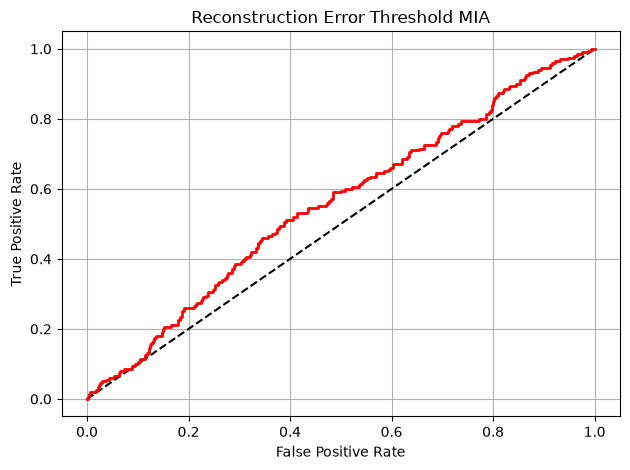

In [10]:
plot_roc(pca_train_err, pca_test_err, "roc.png")

### diffprivlib PCA

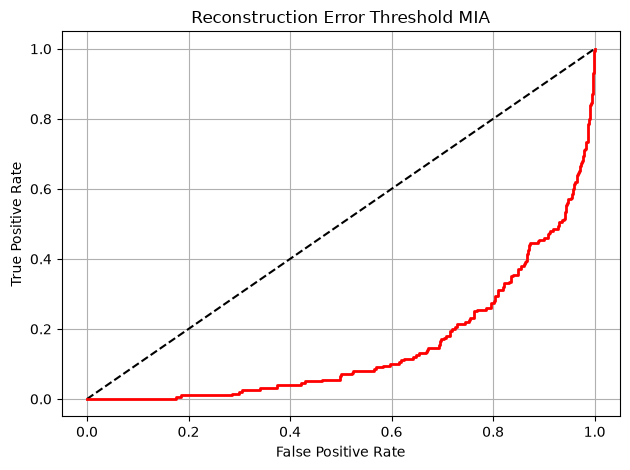

In [11]:
plot_roc(dp_pca_train_err, dp_pca_test_err, "dp_roc.png")

## Run a leave-one-out audit of the scikit-learn PCA

In [12]:
def run_loo(X_train: np.ndarray, full_errors: np.ndarray) -> np.ndarray:
    """Run a leave-one-out audit for PCA reconstruction error."""
    # Compute leave-one-out errors
    n_samples, n_features = X_train.shape
    loo_errors = np.zeros(n_samples)

    for i in range(n_samples):
        # Create a mask to exclude the current sample
        loo_mask = np.ones(n_samples, dtype=bool)
        loo_mask[i] = False

        X_loo_train = X_train[loo_mask]
        target_sample = X_train[i : i + 1]  # Keep 2D shape (1, n_features)

        # Fit PCA on the remaining N-1 samples
        pca_loo = PCA(n_components=N_COMPONENTS)
        pca_loo.fit(X_loo_train)

        # Project and reconstruct the left-out sample
        sample_transformed = pca_loo.transform(target_sample)
        sample_projected = pca_loo.inverse_transform(sample_transformed)

        # Calculate error for this specific left-out sample
        loo_errors[i] = np.mean((target_sample - sample_projected) ** 2)

    # Calculate the leverage impact ratio
    leverage_ratio = loo_errors / (full_errors + 1e-8)

    print(f"Mean Leverage Ratio: {np.mean(leverage_ratio):.2f}x")
    print(f"Median Leverage Ratio: {np.median(leverage_ratio):.2f}x")
    print(f"Max Leverage Ratio: {np.max(leverage_ratio):.2f}x (Most disclosive)")

    return loo_errors

In [13]:
def plot_loo(
    full_errors: np.ndarray, loo_errors: np.ndarray, threshold: float = 1.2
) -> None:
    """Plot full fit vs leave-one-out errors to find high-leverage outliers."""
    plt.figure(figsize=(8, 8))

    # Calculate leverage ratio to use as a color map
    leverage_ratio = loo_errors / (full_errors + 1e-8)

    # Scatter plot of the samples
    scatter = plt.scatter(
        full_errors,
        loo_errors,
        c=leverage_ratio,
        cmap="autumn_r",
        edgecolors="k",
        alpha=0.8,
        s=70,
        zorder=3,
    )

    # Add a 45-degree reference line where Full Error == LOO Error
    max_val = max(np.max(full_errors), np.max(loo_errors)) * 1.05
    plt.plot(
        [0, max_val],
        [0, max_val],
        color="gray",
        linestyle="--",
        alpha=0.7,
        label="Identity Line (Stable)",
        zorder=2,
    )

    # Label data points that have massive leverage (e.g., top 3 highest ratios)
    top_leverage_idx = np.argsort(leverage_ratio)[-3:][::-1]

    print("\nMost vulnerable sample:")
    top_idx = top_leverage_idx[0]
    print(f"Sample index: {top_idx}")
    print(f"Full error: {full_errors[top_idx]:.2f}")
    print(f"LOO error: {loo_errors[top_idx]:.2f}")
    print(f"Leverage ratio: {loo_errors[top_idx] / full_errors[top_idx]:.2f}x")
    print("\n")

    for idx in top_leverage_idx:
        if leverage_ratio[idx] > threshold:  # Only label if it skews the fit
            plt.annotate(
                f"Sample {idx}\n({leverage_ratio[idx]:.1f}x)",
                (full_errors[idx], loo_errors[idx]),
                textcoords="offset points",
                xytext=(10, -5),
                ha="left",
                fontsize=9,
                fontweight="bold",
                bbox={
                    "boxstyle": "round,pad=0.3",
                    "fc": "yellow",
                    "alpha": 0.5,
                    "ec": "gray",
                },
            )

    plt.xlim(0, max_val)
    plt.ylim(0, max_val)

    plt.title("PCA Leave-One-Out Audit: Identifying Leverage Points")
    plt.xlabel("Full Fit Reconstruction Error (Sample Included)")
    plt.ylabel("LOO Reconstruction Error (Sample Excluded)")

    cbar = plt.colorbar(scatter)
    cbar.set_label("Leverage Ratio (LOO Error / Full Error)")

    plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.savefig("loo_plot.png")
    plt.show()

Mean Leverage Ratio: 1.09x
Median Leverage Ratio: 1.07x
Max Leverage Ratio: 2.53x (Most disclosive)

Most vulnerable sample:
Sample index: 477
Full error: 0.76
LOO error: 1.92
Leverage ratio: 2.53x




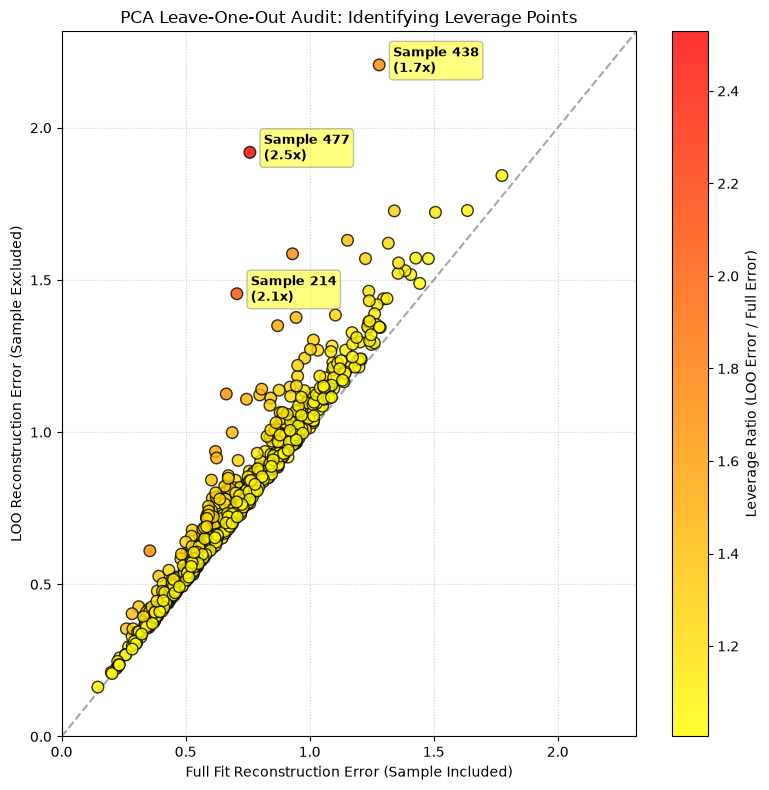

In [14]:
loo_err = run_loo(X_train, pca_train_err)

plot_loo(pca_train_err, loo_err)

## Run a SACRO-ML MIA on the scikit-learn PCA

In [15]:
def run_wca(train_error: np.ndarray, test_error: np.ndarray) -> None:
    """Run SACRO-ML WorstCaseAttack using errors."""
    # WorstCaseAttack currently assumes 2D arrays
    train_error = train_error.reshape(-1, 1)
    test_error = test_error.reshape(-1, 1)

    # Wrap data in a Target object
    target = Target(model=None, proba_train=train_error, proba_test=test_error)

    # Create attack
    attack = WorstCaseAttack(
        n_reps=10,
        n_dummy_reps=0,
        train_beta=5,
        test_beta=2,
        p_thresh=0.05,
        test_prop=0.5,
        output_dir="sacroml_pca",
    )

    # Run the attack
    attack.attack(target)

INFO:sacroml.attacks.worst_case_attack:Running main attack repetitions
INFO:sacroml.attacks.worst_case_attack:Sorting probabilities to leave highest value in first column
INFO:sacroml.attacks.worst_case_attack:Creating MIA data
INFO:sacroml.attacks.worst_case_attack:Rep 1 of 10 split 5
INFO:sacroml.attacks.worst_case_attack:Rep 2 of 10 split 25
INFO:sacroml.attacks.worst_case_attack:Rep 3 of 10 split 36
INFO:sacroml.attacks.worst_case_attack:Rep 4 of 10 split 49
INFO:sacroml.attacks.worst_case_attack:Rep 5 of 10 split 64
INFO:sacroml.attacks.worst_case_attack:Rep 6 of 10 split 81
INFO:sacroml.attacks.worst_case_attack:Rep 7 of 10 split 100
INFO:sacroml.attacks.worst_case_attack:Rep 8 of 10 split 121
INFO:sacroml.attacks.worst_case_attack:Rep 9 of 10 split 144
INFO:sacroml.attacks.worst_case_attack:Rep 10 of 10 split 169
INFO:sacroml.attacks.worst_case_attack:Finished simulating attacks
INFO:sacroml.attacks.worst_case_attack:Finished running attacks
INFO:sacroml.attacks.attack:Generatin

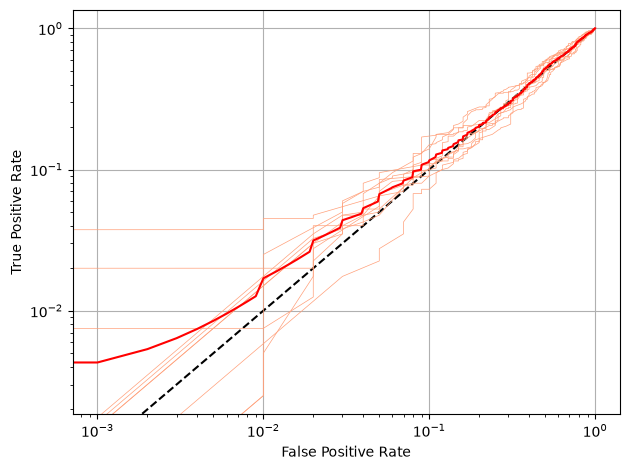

In [16]:
run_wca(pca_train_err, pca_test_err)